# EDA PARA DATASET AUTOS USADOS
# FUENTE: NEOAUTO

# 1 - IMPORTAR LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2 - CARGAMOS EL DATASET

In [2]:
df = pd.read_csv('/content/autos_usados_peru.csv')
df

,url_anuncio,imagen_auto,marca,titulo,anio,precio,kilometraje,transmision,combustible
0,https://neoauto.com/auto/seminuevo/volvo-xc-40...,https://cdn.neoauto.com/elements/autos_usados/...,Volvo,Volvo Xc-40 2024,2024.0,"US$37,490","35,600 km",Automática,Gasolina-Híbrido
1,https://neoauto.com/auto/seminuevo/peugeot-500...,https://cdn.neoauto.com/elements/autos_usados/...,Peugeot,Peugeot 5008 2017,2017.0,"US$22,900","52,362 km",Automática,Gasolina
2,https://neoauto.com/auto/seminuevo/porsche-cay...,https://cdn.neoauto.com/elements/autos_usados/...,Porsche,Porsche Cayenne 2023,2023.0,"US$82,900","26,196 km",Automática - Secuencial,Gasolina
3,https://neoauto.com/auto/seminuevo/audi-q3-201...,https://cdn.neoauto.com/elements/autos_usados/...,Audi,Audi Q3 2016,2016.0,"US$15,900","113,237 km",Automática,Gasolina
4,https://neoauto.com/auto/seminuevo/mercedes-be...,https://cdn.neoauto.com/elements/autos_usados/...,Mercedes-Benz,Mercedes-Benz Gle 400 4matic 2017,2017.0,"US$26,900","58,000 km",Automática,Gasolina
...,...,...,...,...,...,...,...,...,...
2194,https://neoauto.com/auto/usado/nissan-sentra-2...,https://cdn.neoauto.com/elements/autos_usados/...,Nissan,Nissan Sentra 2011,2011.0,"US$8,500","85,000 km",Mecánica,Dual
2195,https://neoauto.com/auto/usado/renault-master-...,https://cdn.neoauto.com/elements/autos_usados/...,Renault,Renault Master Minubus 2019,2019.0,"US$29,000","117,318 km",Mecánica,Diesel
2196,https://neoauto.com/auto/usado/ford-territory-...,https://cdn.neoauto.com/elements/autos_usados/...,Ford,Ford Territory 2022,2022.0,"US$17,990","48,000 km",Automática - Secuencial,Gasolina
2197,https://neoauto.com/auto/usado/subaru-all-new-...,https://cdn.neoauto.com/elements/autos_usados/...,Subaru,Subaru All New Forester 2019 2019,2019.0,"US$19,999","98,500 km",Automática - Secuencial,Gasolina


# EDA

In [3]:
df.dtypes

,0
url_anuncio,object
imagen_auto,object
marca,object
titulo,object
anio,float64
precio,object
kilometraje,object
transmision,object
combustible,object


# ELIMINAMOS LOS CAMPOS QUE NO SE NECESITAN

In [5]:
df_cleaned = df[['anio','precio','kilometraje','transmision','combustible']]
df_cleaned

,anio,precio,kilometraje,transmision,combustible
0,2024.0,"US$37,490","35,600 km",Automática,Gasolina-Híbrido
1,2017.0,"US$22,900","52,362 km",Automática,Gasolina
2,2023.0,"US$82,900","26,196 km",Automática - Secuencial,Gasolina
3,2016.0,"US$15,900","113,237 km",Automática,Gasolina
4,2017.0,"US$26,900","58,000 km",Automática,Gasolina
...,...,...,...,...,...
2194,2011.0,"US$8,500","85,000 km",Mecánica,Dual
2195,2019.0,"US$29,000","117,318 km",Mecánica,Diesel
2196,2022.0,"US$17,990","48,000 km",Automática - Secuencial,Gasolina
2197,2019.0,"US$19,999","98,500 km",Automática - Secuencial,Gasolina


# VERIFICAMOS NULOS

In [8]:
df_cleaned.isnull().sum()

,0
anio,0
precio,0
kilometraje,0
transmision,0
combustible,0


In [7]:
df_cleaned.dropna(inplace=True)

/tmp/ipykernel_67709/2343921619.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.dropna(inplace=True)


In [9]:
df_cleaned.shape

(2186, 5)

# CONVERTIMOS LOS TIPOS DE DATOS

In [10]:
df_cleaned.dtypes

,0
anio,float64
precio,object
kilometraje,object
transmision,object
combustible,object


In [11]:
df_cleaned['precio'] = df_cleaned['precio'].str.replace('US$', '', regex=False).str.replace(',', '', regex=False).astype(float)
df_cleaned.dtypes

/tmp/ipykernel_67709/3259436967.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['precio'] = df_cleaned['precio'].str.replace('US$', '', regex=False).str.replace(',', '', regex=False).astype(float)


,0
anio,float64
precio,float64
kilometraje,object
transmision,object
combustible,object


In [12]:
df_cleaned['kilometraje'] = df_cleaned['kilometraje'].str.replace(' km', '', regex=False).str.replace(',', '', regex=False).astype(float)
df_cleaned.dtypes

/tmp/ipykernel_67709/996223931.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['kilometraje'] = df_cleaned['kilometraje'].str.replace(' km', '', regex=False).str.replace(',', '', regex=False).astype(float)


,0
anio,float64
precio,float64
kilometraje,float64
transmision,object
combustible,object


In [13]:
df_cleaned

,anio,precio,kilometraje,transmision,combustible
0,2024.0,37490.0,35600.0,Automática,Gasolina-Híbrido
1,2017.0,22900.0,52362.0,Automática,Gasolina
2,2023.0,82900.0,26196.0,Automática - Secuencial,Gasolina
3,2016.0,15900.0,113237.0,Automática,Gasolina
4,2017.0,26900.0,58000.0,Automática,Gasolina
...,...,...,...,...,...
2194,2011.0,8500.0,85000.0,Mecánica,Dual
2195,2019.0,29000.0,117318.0,Mecánica,Diesel
2196,2022.0,17990.0,48000.0,Automática - Secuencial,Gasolina
2197,2019.0,19999.0,98500.0,Automática - Secuencial,Gasolina


# NORMALIZAMOS VARIABLES CATEGORICAS

In [14]:
df_cleaned['transmision'].value_counts()

,count
transmision,
Automática - Secuencial,952
Automática,797
Mecánica,437


In [15]:
df_cleaned['combustible'].value_counts()

,count
combustible,
Gasolina,1712
Dual,132
Diesel,122
Gasolina-Híbrido,92
GLP,37
GNV,30
Eléctrico,26
Híbrido,20
DIESEL,11


In [16]:
df_cleaned['combustible'] = np.where(
    df_cleaned['combustible'].isin(['Gasolina', 'GASOLINA']),
    'Gasolina',
    'Otros'
)
df_cleaned['combustible'].value_counts()

/tmp/ipykernel_67709/379609050.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['combustible'] = np.where(


,count
combustible,
Gasolina,1714
Otros,472


In [17]:
df_cleaned

,anio,precio,kilometraje,transmision,combustible
0,2024.0,37490.0,35600.0,Automática,Otros
1,2017.0,22900.0,52362.0,Automática,Gasolina
2,2023.0,82900.0,26196.0,Automática - Secuencial,Gasolina
3,2016.0,15900.0,113237.0,Automática,Gasolina
4,2017.0,26900.0,58000.0,Automática,Gasolina
...,...,...,...,...,...
2194,2011.0,8500.0,85000.0,Mecánica,Otros
2195,2019.0,29000.0,117318.0,Mecánica,Otros
2196,2022.0,17990.0,48000.0,Automática - Secuencial,Gasolina
2197,2019.0,19999.0,98500.0,Automática - Secuencial,Gasolina


# ELIMINAR OUTLIERS

## DEFINIMOS VARIABLE A UTILIZAR

In [18]:
variable = 'precio'
data = df_cleaned[variable]

## DETERMINAMOS MEDIDAS DE TENDENCIA CENTRAL

In [50]:
mean_val = data.mean()
median_val = data.median()
mode_val = data.mode()[0]

print(f"📊 Medidas de tendencia central de {variable}")
print(f"Media (μ): {mean_val:.2f}")
print(f"Mediana: {median_val:.2f}")
print(f"Moda: {mode_val:.2f}")

📊 Medidas de tendencia central de precio
Media (μ): 20442.63
Mediana: 18900.00
Moda: 19900.00


# DETERMINAMOS MEDIDAS DE DISPERSIÓN

In [51]:
variance_val = data.var()
std_val = data.std()
range_val = data.max() - data.min()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1
print(f"\n📈 Medidas de dispersión de {variable}")
print(f"Varianza (σ²): {variance_val:.2f}")
print(f"Desviación estándar (σ): {std_val:.2f}")
print(f"Rango: {range_val:.2f}")
print(f"Rango intercuartílico (IQR): {iqr:.2f}")


📈 Medidas de dispersión de precio
Varianza (σ²): 90010767.60
Desviación estándar (σ): 9487.40
Rango: 45000.00
Rango intercuartílico (IQR): 12700.00


# DEFINIMOS RANGOS Y RANGO INTERCUARTILICO PARA UBICAR OUTLIERS

In [52]:
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = data[(data < limite_inferior) | (data > limite_superior)]

print(f"\n⚠️ Detección de Outliers (Regla del IQR) para {variable}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Número de outliers detectados: {len(outliers)}")


⚠️ Detección de Outliers (Regla del IQR) para precio
Límite inferior: -5750.00
Límite superior: 45050.00
Número de outliers detectados: 0


# GRAFICAMOS OUTLIERS

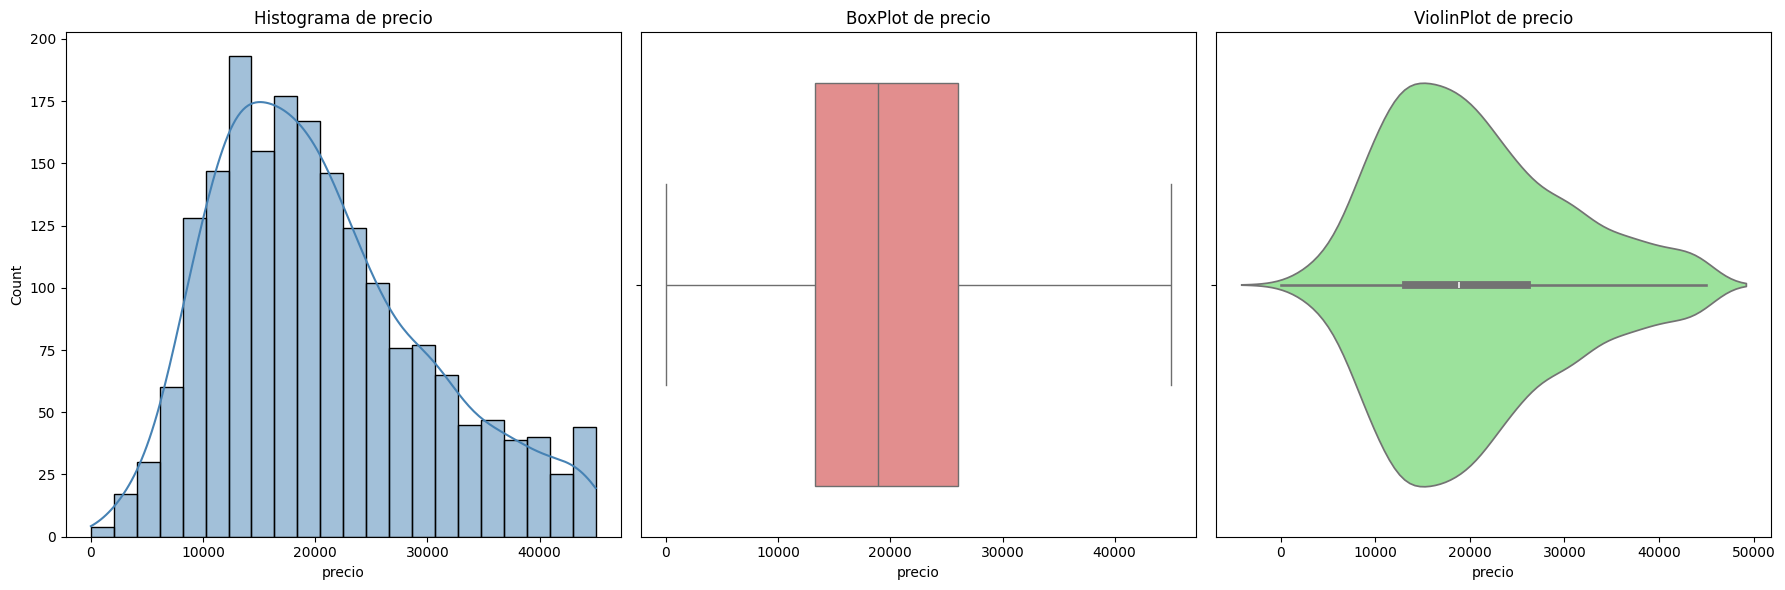

In [53]:
fig,axes = plt.subplots(1,3,figsize=(18,6))

#histograma
sns.histplot(data,kde=True,color='steelblue',ax=axes[0])
axes[0].set_title(f'Histograma de {variable}')

#boxplot
sns.boxplot(x=data,color='lightcoral',ax=axes[1])
axes[1].set_title(f'BoxPlot de {variable}')

#violinplot
sns.violinplot(x=data,color='lightgreen',ax=axes[2])
axes[2].set_title(f'ViolinPlot de {variable}')

plt.tight_layout()
plt.show()

# ELIMINAR OUTLIERS

In [48]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [49]:
df_cleaned = remove_outliers(df_cleaned,variable)
data = df_cleaned[variable]

In [54]:
df_cleaned.shape

(1908, 5)

# GUARDAMOS DATASET LIMPIO

In [55]:
df_cleaned.to_csv('autos_cleaned.csv',index=None)